## Download Physionet MIMIC IV datasets

In [4]:
try:
    import google.colab
    print("Running in Colab! ... downloading everything...")
    !wget -np https://physionet.org/files/mimic-iv-demo/2.2/hosp/patients.csv.gz -O data/patients.csv.gz
    !wget -np https://physionet.org/files/mimic-iv-demo/2.2/hosp/admissions.csv.gz -O data/admissions.csv.gz
    !wget -np https://physionet.org/files/mimic-iv-demo/2.2/hosp/diagnoses_icd.csv.gz -O data/diagnoses_icd.csv.gz
    !wget -np https://physionet.org/files/mimic-iv-demo/2.2/hosp/d_icd_diagnoses.csv.gz -O data/d_icd_diagnoses.csv.gz
    !wget -np https://physionet.org/files/mimic-iv-demo/2.2/hosp/procedures_icd.csv.gz -O data/procedures_icd.csv.gz
    !wget -np https://physionet.org/files/mimic-iv-demo/2.2/hosp/d_icd_procedures.csv.gz -O data/d_icd_procedures.csv.gz
    !wget -np https://physionet.org/files/mimic-iv-demo/2.2/hosp/prescriptions.csv.gz -O data/prescriptions.csv.gz
    !wget -np https://physionet.org/files/mimic-iv-demo/2.2/hosp/emar.csv.gz -O data/emar.csv.gz
    !gunzip -f data/*.gz
except:
  print("Not running in Colab!")


Not running in Colab!


In [5]:
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
import os

def read_csv(filename):
    total_lines = sum(1 for _ in open(filename))
    with tqdm(total=int(total_lines), desc=f'Loading {os.path.basename(filename)}:') as bar:
        # do not skip any of the rows, but update the progress bar instead
        filecontent = pd.read_csv(filename, skiprows=lambda x: bar.update(1) and False)
    return filecontent

DATA_PATH = "../mimic-iv" #"<your-path-to-mimic-iv-datafiles>"

patients = read_csv(os.path.join(DATA_PATH, "patients.csv"))
admissions = read_csv(os.path.join(DATA_PATH, "admissions.csv"))
diagnoses = read_csv(os.path.join(DATA_PATH, "diagnoses_icd.csv"))
d_icd_diag = read_csv(os.path.join(DATA_PATH, "d_icd_diagnoses.csv"))
procedures = read_csv(os.path.join(DATA_PATH, "procedures_icd.csv"))
d_icd_proc = read_csv(os.path.join(DATA_PATH, "d_icd_procedures.csv"))
#prescriptions = read_csv(os.path.join(DATA_PATH, "prescriptions.csv"))
emar = read_csv(os.path.join(DATA_PATH, "emar.csv"))

Loading patients.csv::   0%|          | 0/364628 [00:00<?, ?it/s]

Loading admissions.csv::   0%|          | 0/546029 [00:00<?, ?it/s]

Loading diagnoses_icd.csv::   0%|          | 0/6364489 [00:00<?, ?it/s]

Loading d_icd_diagnoses.csv::   0%|          | 0/112108 [00:00<?, ?it/s]

Loading procedures_icd.csv::   0%|          | 0/859656 [00:00<?, ?it/s]

Loading d_icd_procedures.csv::   0%|          | 0/86424 [00:00<?, ?it/s]

Loading emar.csv::   0%|          | 0/42808594 [00:00<?, ?it/s]

## Selezione i pazienti con primary disease == asplenia

In [7]:
import pandas as pd 
onco_codes = pd.read_csv("asplenic_icd_codes/Onco.csv", names=['icd_code', 'icd_version', 'long_title'], sep=';', comment='#')
cha_codes = pd.read_csv("asplenic_icd_codes/CHA.csv", names=['icd_code', 'icd_version', 'long_title'], sep=';', comment='#')
thala_codes = pd.read_csv("asplenic_icd_codes/Thalassemia.csv", names=['icd_code', 'icd_version', 'long_title'], sep=';', comment='#')
scd_codes = pd.read_csv("asplenic_icd_codes/SCD.csv", names=['icd_code', 'icd_version', 'long_title'], sep=';', comment='#')
imm_codes = pd.read_csv("asplenic_icd_codes/Immunodef.csv", names=['icd_code', 'icd_version', 'long_title'], sep=';', comment='#')
spleen_codes = pd.concat([onco_codes,cha_codes,thala_codes,scd_codes,imm_codes])
spleen_codes

,icd_code,icd_version,long_title
0,1537,9,Malignant neoplasm of splenic flexure
1,2894,9,Hypersplenism
2,28951,9,Chronic congestive splenomegaly
3,28953,9,Neutropenic splenomegaly
4,44283,9,Aneurysm of splenic artery
...,...,...,...
16,D838,10,Other common variable immunodeficiencies
17,D839,10,"Common variable immunodeficiency, unspecified"
18,D84,10,Other immunodeficiencies
19,D848,10,Other specified immunodeficiencies


Pre-admission absence of spleen found: 450
Asplenic primary disease found: 670
Asplenic disease found: 670
Splenectomized patients found: 544
Total patients patients: 1431


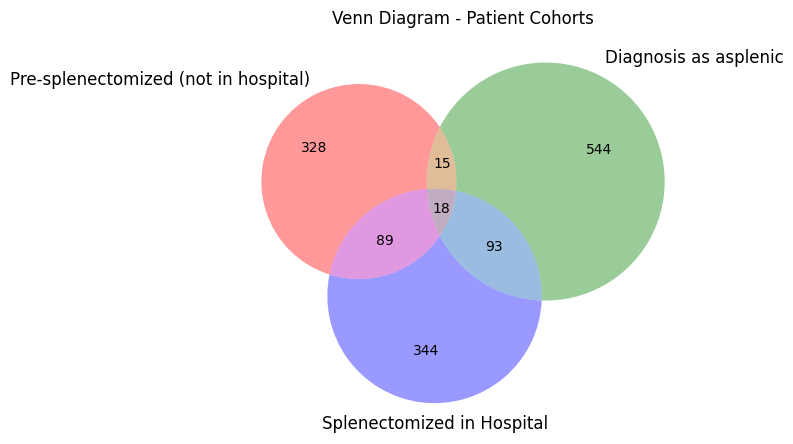

In [4]:
diagnoses_full = diagnoses.merge(
    d_icd_diag,
    on=["icd_code", "icd_version"],
    how="left"
)

# individua tutti i pazienti che hanno registrato (in qualsisi ricovero) l'assenza di milza pregressa 
no_spleen_diag = diagnoses_full[
    diagnoses_full["long_title"].str.contains(
        "asplenia|absence of spleen|absence and malformations of spleen|postsplenectomy",
        case=False,
        na=False
    )
]
no_spleen_patients = list(set(no_spleen_diag["subject_id"]))
print(f"Pre-admission absence of spleen found: {len(no_spleen_patients)}")

# individua i pazienti che hanno come disease rgistrata al primo ricovero tra quell identificate insieme a 
# Maddalena come categorie di asplenici
primary = diagnoses_full[diagnoses_full["seq_num"] == 1]
asplenia_first_diag = primary[
    primary["icd_code"].isin(spleen_codes['icd_code'].values)
]
asplenic_first_diag_patients = list(set(asplenia_first_diag["subject_id"]))
print(f"Asplenic primary disease found: {len(asplenic_first_diag_patients)}")

asplenia_diag = diagnoses_full[(diagnoses_full["seq_num"] == 1 ) & (
    diagnoses_full["icd_code"].isin(spleen_codes['icd_code'].values))
]
asplenic_patients = list(set(asplenia_diag["subject_id"]))
print(f"Asplenic disease found: {len(asplenic_patients)}")

# individua i pazienti che in un qualsiasi ricovero hanno subito una (o più) spelenctomie
# e ne determina 'età al giorno della splenectomia
procedures["icd_code_clean"] = procedures["icd_code"].str.replace(".", "", regex=False)

splenectomy = procedures[
    (procedures["icd_code_clean"].str.startswith("415")) |
    (procedures["icd_code_clean"].str.startswith("414")) |
    (procedures["icd_code_clean"].str.startswith("07TP"))
]
splenectomy_full = splenectomy.merge(
    d_icd_proc,
    on=["icd_code", "icd_version"],
    how="left"
)
admissions["admittime"] = pd.to_datetime(admissions["admittime"])
splenectomy_full = splenectomy_full.merge(
    admissions[["subject_id", "hadm_id", "admittime"]],
    on=["subject_id", "hadm_id"],
    how="left"
)
splenectomy_full = splenectomy_full.merge(
    patients[["subject_id", "anchor_age", "anchor_year"]],
    on="subject_id",
    how="left"
)
splenectomy_full["event_year"] = splenectomy_full["admittime"].dt.year

splenectomy_full["age_at_splenectomy"] = (
    splenectomy_full["anchor_age"] +
    (splenectomy_full["event_year"] - splenectomy_full["anchor_year"])
)
splenectomized_patients = list(set(splenectomy_full["subject_id"]))
print(f"Splenectomized patients found: {len(splenectomized_patients)}")

all_asplenic_patients = list(set(no_spleen_patients) | set(splenectomized_patients) | set(asplenic_patients))
print(f"Total patients patients: {len(all_asplenic_patients)}")

## confronta diagrammi di venn degli insiemi
import matplotlib.pyplot as plt
from matplotlib_venn import venn3

# Esempio: tre insiemi di subject_id
A = set(no_spleen_patients)
B = set(asplenic_patients)
C = set(splenectomized_patients)

plt.figure(figsize=(6,6))

venn3([A, B, C],
      set_labels=('Pre-splenectomized (not in hospital)', 'Diagnosis as asplenic', 'Splenectomized in Hospital'))

plt.title("Venn Diagram - Patient Cohorts")
plt.savefig("venn.png")
plt.show()


## Filter patients by disease

In [5]:
selected_idxs = all_asplenic_patients
diagnoses = diagnoses[diagnoses["subject_id"].isin(selected_idxs)]
procedures = procedures[procedures["subject_id"].isin(selected_idxs)]
#prescriptions = prescriptions[prescriptions["subject_id"].isin(selected_idxs)]
admissions = admissions[admissions["subject_id"].isin(selected_idxs)]
emar = emar[emar["subject_id"].isin(selected_idxs)]
patients = patients[patients["subject_id"].isin(selected_idxs)]

## Gender and age distribution of patients

In [6]:
patients['base_pathology'] = patients['subject_id'].apply(lambda x:
    "OD - Oncological Diseases" if asplenia_diag[asplenia_diag['subject_id'] == x]['icd_code'].isin(onco_codes['icd_code'].values).any()
    else "CHA - Congenital Hemolytic Anemias" if asplenia_diag[asplenia_diag['subject_id'] == x]['icd_code'].isin(cha_codes['icd_code'].values).any()
    else "THA - Thalassemia" if asplenia_diag[asplenia_diag['subject_id'] == x]['icd_code'].isin(thala_codes['icd_code'].values).any()
    else "AIHD - Autoimmune Hematological Diseases" if asplenia_diag[asplenia_diag['subject_id'] == x]['icd_code'].isin(imm_codes['icd_code'].values).any()
    else "SCD - Sicke Cell Disease" if asplenia_diag[asplenia_diag['subject_id'] == x]['icd_code'].isin(scd_codes['icd_code'].values).any()
    else "SP - Splenectomized"
)


In [7]:
patients['base_pathology'].value_counts()

base_pathology
SP - Splenectomized                         761
OD - Oncological Diseases                   504
CHA - Congenital Hemolytic Anemias          137
SCD - Sicke Cell Disease                     20
AIHD - Autoimmune Hematological Diseases      8
THA - Thalassemia                             1
Name: count, dtype: int64

In [8]:
patients['age_group'] = patients['anchor_age'].apply(lambda x: "young" if x < 35 else "mature" if x < 55 else "elder" if x < 75 else "geriatric")
counts = patients.groupby(['age_group', 'gender']).size().unstack(fill_value=0)
print(counts.to_latex())

\begin{tabular}{lrr}
\toprule
gender & F & M \\
age_group &  &  \\
\midrule
elder & 284 & 322 \\
geriatric & 86 & 100 \\
mature & 179 & 223 \\
young & 110 & 127 \\
\bottomrule
\end{tabular}



In [9]:
admissions['admission_location'].value_counts()

admission_location
EMERGENCY ROOM                            3101
PHYSICIAN REFERRAL                        2259
WALK-IN/SELF REFERRAL                      783
TRANSFER FROM HOSPITAL                     686
CLINIC REFERRAL                            282
PROCEDURE SITE                             137
TRANSFER FROM SKILLED NURSING FACILITY      83
PACU                                        57
INTERNAL TRANSFER TO OR FROM PSYCH          14
INFORMATION NOT AVAILABLE                    6
AMBULATORY SURGERY TRANSFER                  3
Name: count, dtype: int64

## Compute events

### calcola i farmaci dalla tabell `emar.csv`

In [10]:
import re
VACCINATION_KEYWORDS = r"(influenza|flu)|(pneumo\w*)|(mening\w*)|(hepatitis\s*b?)|(tdap|tetanus|diphtheria|pertussis)|(hib)|(covid)"
EXCLUDE_PATTERN = r"(flut|fluc|fluor|flush|fluid|test|panel)"

def is_vaccine(text):
    if pd.isna(text):
        return False
    text = str(text)
    # escludi prima
    if re.search(EXCLUDE_PATTERN, text, re.IGNORECASE):
        return False
    # poi verifica vaccini
    return bool(re.search(VACCINATION_KEYWORDS, text, re.IGNORECASE))

emar_events = emar[[
    "subject_id",
    "medication",
    "charttime"
]].copy()

emar_events = emar_events.rename(columns={
    "medication": "event",
    "charttime": "event_date"
})
emar_events["event_date"] = pd.to_datetime(emar_events["event_date"]).dt.date
#emar_events["is_vaccine"] = emar_events["event"].apply(is_vaccine)

emar_events["type"] = emar_events["event"].apply(
    lambda x: "vaccination" if is_vaccine(x) else "drug"
)
emar_events["code"] = emar_events["event"]
emar_events["code_type"] = "EMAR-MED"
emar_events.head()

,subject_id,event,event_date,type,code,code_type
73638,10015988,Sodium Chloride 0.9% Flush,2136-06-04,drug,Sodium Chloride 0.9% Flush,EMAR-MED
73639,10015988,Insulin,2136-06-04,drug,Insulin,EMAR-MED
73640,10015988,Erythromycin 0.5% Ophth Oint,2136-06-04,drug,Erythromycin 0.5% Ophth Oint,EMAR-MED
73641,10015988,CefePIME,2136-06-04,drug,CefePIME,EMAR-MED
73642,10015988,Erythromycin 0.5% Ophth Oint,2136-06-04,drug,Erythromycin 0.5% Ophth Oint,EMAR-MED


In [11]:
emar_events['type'].value_counts()

type
drug           811346
vaccination      2612
Name: count, dtype: int64

### calcola le terapie, interventi

In [12]:
import re

SURGERY_KEYWORDS = r"(surgery|excision|resection|repair|removal|laparotomy|amputation|splenectomy)"
SPLENECTOMY_KEYWORDS = r"(splenectomy|removal of spleen|spleen excision)"
NON_SURGICAL_KEYWORDS = r"(insertion|catheter|infusion|dialysis|ventilation|biopsy)"

def classify_procedure(text):
    if pd.isna(text):
        return "unknown"
    
    t = str(text).lower()

    # 🔴 priorità massima: splenectomie
    if re.search(SPLENECTOMY_KEYWORDS, t):
        return "splenectomy"

    # 🔵 chirurgia generale
    if re.search(SURGERY_KEYWORDS, t):
        return "surgery"

    # 🟡 terapie / procedure non chirurgiche
    if re.search(NON_SURGICAL_KEYWORDS, t):
        return "therapy"

    return "therapy" #"other_procedure"

procedures_m = procedures.merge(
    d_icd_proc[["icd_code", "long_title"]],
    on="icd_code",
    how="left"
)
proc_join = procedures_m.merge(
    admissions[["hadm_id", "admittime", "subject_id"]],
    on="hadm_id",
    how="left",
    suffixes=('', '_remove')
)
proc_join["event_date"] = pd.to_datetime(proc_join["admittime"]).dt.date
proc_join["type"] = proc_join["long_title"].apply(classify_procedure)

proc_join["event"] = proc_join["long_title"]

proc_events = proc_join[[
    "subject_id",
    "event",
    "event_date",
    "icd_code",
    "icd_version",
    "type"
]].copy()
proc_events.rename(columns={'icd_code':'code'}, inplace=True)
def map_code_type(v):
    if pd.isna(v):
        return None
    if str(v) in ["9", 9]:
        return "ICD-9-PCS"
    if str(v) in ["10", 10]:
        return "ICD-10-PCS"
    return "UNKNOWN"

proc_events["code_type"] = proc_events["icd_version"].apply(map_code_type)
proc_events.head()

,subject_id,event,event_date,code,icd_version,type,code_type
0,10008924,Percutaneous abdominal drainage,2139-08-20,5491,9,therapy,ICD-9-PCS
1,10008924,Alcohol detoxification,2139-07-08,9462,9,therapy,ICD-9-PCS
2,10008924,Percutaneous abdominal drainage,2139-07-08,5491,9,therapy,ICD-9-PCS
3,10008924,Percutaneous abdominal drainage,2139-07-08,5491,9,therapy,ICD-9-PCS
4,10008924,Percutaneous abdominal drainage,2139-07-08,5491,9,therapy,ICD-9-PCS


In [13]:
import re

INFECTION_PATTERN = r"""
(sepsis|septicaemia|septic|infection|infect|pneumonia|
abscess|cellulitis|meningitis|encephalitis|endocarditis|
bacteremia|fungal|viral|tb|tuberculosis|urinary tract infection|uti)
"""
def is_infection(text):
    if pd.isna(text):
        return False
    
    return bool(
        re.search(INFECTION_PATTERN, str(text), re.IGNORECASE | re.VERBOSE)
    )

diagnoses_m = diagnoses.merge(
    d_icd_diag[["icd_code", "long_title"]],
    on="icd_code",
    how="left"
)
diag_join = diagnoses_m.merge(
    admissions[["hadm_id", "admittime", "subject_id"]],
    on="hadm_id",
    how="left",
    suffixes=('', '_remove')
)
diag_join["event_date"] = pd.to_datetime(diag_join["admittime"]).dt.date

diagnosis_events = diag_join[[
    "subject_id", "icd_code", "icd_version", "event_date", "long_title"
]].rename(columns={
    "long_title": "event", "icd_code" : "code"
})
diagnosis_events["type"] = diagnosis_events["event"].apply(
    lambda x: "infection" if is_infection(x) else "disease"
)
diagnosis_events["code_type"] = diagnosis_events['icd_version'].apply(lambda x: f"ICD-{x}-CM")
diagnosis_events.head()

,subject_id,code,icd_version,event_date,event,type,code_type
0,10008924,86509,9,2139-08-20,Other injury into spleen without mention of op...,disease,ICD-9-CM
1,10008924,78959,9,2139-08-20,Other ascites,disease,ICD-9-CM
2,10008924,2761,9,2139-08-20,Hyposmolality and/or hyponatremia,disease,ICD-9-CM
3,10008924,E8889,9,2139-08-20,Unspecified fall,disease,ICD-9-CM
4,10008924,E8889,9,2139-08-20,Other specified metabolic disorders,disease,ICD-9-CM


In [14]:
all_events = pd.concat([
    diagnosis_events,
    proc_events,
    emar_events,
], ignore_index=True)

# Remove events with no data
all_events = all_events.dropna(subset=["event_date"])

# Convert patient id into string for JSON
all_events["subject_id"] = all_events["subject_id"].astype(str)
all_events["type"].value_counts()
all_events

,subject_id,code,icd_version,event_date,event,type,code_type
0,10008924,86509,9.0,2139-08-20,Other injury into spleen without mention of op...,disease,ICD-9-CM
1,10008924,78959,9.0,2139-08-20,Other ascites,disease,ICD-9-CM
2,10008924,2761,9.0,2139-08-20,Hyposmolality and/or hyponatremia,disease,ICD-9-CM
3,10008924,E8889,9.0,2139-08-20,Unspecified fall,disease,ICD-9-CM
4,10008924,E8889,9.0,2139-08-20,Other specified metabolic disorders,disease,ICD-9-CM
...,...,...,...,...,...,...,...
930773,19989783,Vitamin D,NaN,2126-06-18,Vitamin D,drug,EMAR-MED
930774,19989783,Sodium Chloride 0.9% Flush,NaN,2126-06-18,Sodium Chloride 0.9% Flush,drug,EMAR-MED
930775,19989783,Metoprolol Tartrate,NaN,2126-06-18,Metoprolol Tartrate,drug,EMAR-MED
930776,19989783,Sodium Chloride 0.9% Flush,NaN,2126-06-18,Sodium Chloride 0.9% Flush,drug,EMAR-MED


## Extract info of patients with multiple admissions

In [15]:
multi_admit = admissions.groupby("subject_id").size().reset_index(name="num_admissions")
multi_admit = multi_admit[multi_admit["num_admissions"] > 1]
admissions_multi = admissions[admissions["subject_id"].isin(multi_admit["subject_id"])]
admissions_multi

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag
513,10008924,22988516,2139-08-20 02:27:00,2139-08-22 18:48:00,NaN,URGENT,P73VYI,TRANSFER FROM HOSPITAL,HOME,Medicaid,English,SINGLE,WHITE,NaN,NaN,0
514,10008924,23676183,2139-07-08 21:28:00,2139-07-29 16:30:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,Medicaid,English,SINGLE,WHITE,NaN,NaN,0
515,10008924,27441295,2139-04-13 21:34:00,2139-04-22 14:56:00,NaN,EW EMER.,P19UTS,EMERGENCY ROOM,HOME,Other,English,SINGLE,WHITE,2139-04-13 16:14:00,2139-04-14 00:03:00,0
1056,10019003,21457723,2155-07-10 17:48:00,2155-07-18 16:59:00,NaN,EW EMER.,P5069B,TRANSFER FROM HOSPITAL,HOME,Medicare,English,WIDOWED,WHITE,2155-07-10 12:46:00,2155-07-10 19:03:00,0
1057,10019003,25508812,2155-05-22 21:46:00,2155-05-30 03:30:00,NaN,OBSERVATION ADMIT,P36S63,PHYSICIAN REFERRAL,HOME,Medicare,English,WIDOWED,WHITE,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
545424,19989783,23110090,2130-03-15 22:37:00,2130-03-26 16:30:00,NaN,OBSERVATION ADMIT,P2915M,PHYSICIAN REFERRAL,HOME HEALTH CARE,Medicare,English,SINGLE,BLACK/AFRICAN AMERICAN,2130-03-15 13:24:00,2130-03-16 00:01:00,0
545425,19989783,24282820,2130-08-02 17:27:00,2130-08-07 13:46:00,NaN,EW EMER.,P07KMB,WALK-IN/SELF REFERRAL,CHRONIC/LONG TERM ACUTE CARE,Medicare,English,SINGLE,BLACK/AFRICAN AMERICAN,2130-08-02 12:52:00,2130-08-02 18:31:00,0
545426,19989783,25490687,2126-08-11 00:00:00,2126-08-28 12:53:00,NaN,DIRECT EMER.,P32VJE,PHYSICIAN REFERRAL,HOME HEALTH CARE,Private,English,SINGLE,BLACK/AFRICAN AMERICAN,NaN,NaN,0
545427,19989783,26984195,2130-07-12 08:34:00,2130-08-01 15:50:00,NaN,OBSERVATION ADMIT,P42XKM,PHYSICIAN REFERRAL,CHRONIC/LONG TERM ACUTE CARE,Medicare,English,SINGLE,BLACK/AFRICAN AMERICAN,2130-07-12 06:35:00,2130-07-12 09:01:00,0


## Concat all together

In [16]:
from collections import defaultdict
import json

patient_dict = defaultdict(list)

for _, row in tqdm(all_events.iterrows(), total=len(all_events), desc='Processing Events'):
    subj_id = row["subject_id"]
    event_entry = {
        "type": row["type"],
        "event": str(row["event"]),
        "date": str(row["event_date"]),
        "code": str(row["code"]),
        "code_type": str(row["code_type"]),
        "code_descr": str(row["event"])
    }
    patient_dict[subj_id].append(event_entry)


for subj_id, events in tqdm(patient_dict.items(), total=len(patient_dict), desc='Events to Patients'):
    events_sorted = sorted(
        events,
        key=lambda e: e["date"]
    )
    patient_dict[subj_id] = events_sorted

Processing Events:   0%|          | 0/930778 [00:00<?, ?it/s]

Events to Patients:   0%|          | 0/1431 [00:00<?, ?it/s]

## Show the outcome of last admission 
For each patient:

+ find last admission time (`admittime`)

+ take `hospital_expire_flag` of last admision (dead or alive)

In [17]:
admissions["admittime"] = pd.to_datetime(admissions["admittime"])

# Trova ultima admission per paziente
last_adm = admissions.sort_values("admittime").groupby("subject_id").tail(1)

# Keep only subject_id and expire flag
last_adm = last_adm[["subject_id", "hospital_expire_flag"]]

# Convert subject_id a string (come nel tuo patient_dict)
last_adm["subject_id"] = last_adm["subject_id"].astype(str)
last_adm

,subject_id,hospital_expire_flag
146808,12708660,0
424237,17773866,1
404939,17420450,0
428212,17846441,0
285364,15242781,0
...,...,...
1949,10036086,0
229627,14226649,0
383803,17029405,0
200443,13686614,0


## Stampa cause di morte

In [18]:

admissions["admittime"] = pd.to_datetime(admissions["admittime"])

# Ultimo ricovero per paziente
last_adm = admissions.sort_values("admittime").groupby("subject_id").last().reset_index()

# Pazienti morti in ospedale
dead = last_adm[last_adm["hospital_expire_flag"] == 1]

# Join con diagnosi
dead_diag = dead.merge(diagnoses, on=["subject_id", "hadm_id"])

# Diagnosi principale
cause_of_death = dead_diag[dead_diag["seq_num"] == 1]

# 🔴 JOIN CON DESCRIZIONE ICD
cause_of_death = cause_of_death.merge(
    d_icd_diag,
    on=["icd_code", "icd_version"],
    how="left"
)

# Output finale
#print(
cause_of_death[[
    "subject_id",
    "hadm_id",
    "icd_code",
    "long_title",   # 👈 descrizione testuale
]]#.head()

cause_of_death = cause_of_death.rename(columns={"long_title": "cause_of_death"})
cod_df = cause_of_death[["subject_id", "cause_of_death"]].drop_duplicates()

## Prendi genere e altre info da PATIENTS
+ Merge informazioni statiche

In [19]:
# select useful columns
patients_info = patients[["subject_id", "gender", "age_group", "base_pathology"]]
patient_static = patients_info.merge(
    last_adm,
    on="subject_id",
    how="left"
)
patient_static
#all_patients = admissions[["subject_id"]].drop_duplicates()

patient_static = patient_static.merge(
    cod_df,
    on="subject_id",
    how="left"
)
patient_static['cause_of_death'].value_counts()

cause_of_death
Sepsis, unspecified organism                                         11
Encounter for palliative care                                         9
Unspecified septicemia                                                8
Secondary malignant neoplasm of other digestive organs and spleen     5
Other specified sepsis                                                3
                                                                     ..
Acute duodenal ulcer with hemorrhage                                  1
Sepsis due to Methicillin resistant Staphylococcus aureus             1
Bloodstream infection due to central venous catheter                  1
Acquired hemolytic anemia, unspecified                                1
Cerebral artery occlusion, unspecified with cerebral infarction       1
Name: count, Length: 91, dtype: int64

In [20]:
patient_static['hospital_expire_flag'].value_counts(dropna=False)

hospital_expire_flag
0    1301
1     130
Name: count, dtype: int64

In [21]:

counts = patient_static.groupby(['age_group', 'gender']).agg(
    total=('hospital_expire_flag', 'size'),          # totale pazienti
    dead=('hospital_expire_flag', 'sum')             # numero deceduti (assumendo 1=dead, 0=alive)
).unstack(fill_value=0)

print(counts.to_latex())

\begin{tabular}{lrrrr}
\toprule
 & \multicolumn{2}{r}{total} & \multicolumn{2}{r}{dead} \\
gender & F & M & F & M \\
age_group &  &  &  &  \\
\midrule
elder & 284 & 322 & 30 & 35 \\
geriatric & 86 & 100 & 8 & 18 \\
mature & 179 & 223 & 16 & 17 \\
young & 110 & 127 & 0 & 6 \\
\bottomrule
\end{tabular}



## Salva JSON file

In [22]:
final_data = []

for subj_id, events in tqdm(patient_dict.items(), total=len(patient_dict), desc='Patients'):
    
    # Cerca info statiche
    info = patient_static[patient_static["subject_id"] == int(subj_id)]
    
    if not info.empty:
        gender = info.iloc[0]["gender"]
        age_group = info.iloc[0]["age_group"]
        alive_flag = "NO" if info.iloc[0]["hospital_expire_flag"]==1 else "YES"
        primary_disease = info.iloc[0]["base_pathology"]
        cause_of_death = info.iloc[0]["cause_of_death"]
        is_splenectomized = "NO"
        age_at_splenectomy = None
        if int(subj_id) in splenectomized_patients:
            is_splenectomized = "YES"
            x = splenectomy_full[splenectomy_full['subject_id'] == int(subj_id)]['age_at_splenectomy'].values[0]
            age_at_splenectomy = 'pediatric' if x <= 12 else 'adolescent' if x < 18 else "young" if x < 35 else "mature" if x < 55 else "elder" if x < 75 else "geriatric"
        elif int(subj_id) in no_spleen_patients:
            is_splenectomized = "YES"
        else:
            is_splenectomized = "NO"
                   
    else:
        gender = None
        age_group = None
        expire_flag = None
        primary_disease = None
        cause_of_death = None
        is_splenectomized = None
    
    patient_entry = {
        "id": subj_id,
        "gender": gender,
        "age_group": age_group,
        "is_splenectomized?": is_splenectomized,
        "age_at_splenectomy": age_at_splenectomy,
        "base_pathology_area": primary_disease,
        "is_alive?": alive_flag if pd.notnull(alive_flag) else None,
        "cause_of_death": cause_of_death,
        "events": events
    }
    
    final_data.append(patient_entry)
import json

with open(f"mimic-iv_asplenic_{len(selected_idxs)}_new.json", "w") as f:
    json.dump(final_data, f, indent=2)


Patients:   0%|          | 0/1431 [00:00<?, ?it/s]

In [23]:
print(spleen_codes.to_latex(index=False))

\begin{tabular}{lrl}
\toprule
icd_code & icd_version & long_title \\
\midrule
1537 & 9 & Malignant neoplasm of splenic flexure \\
2894 & 9 & Hypersplenism \\
28951 & 9 & Chronic congestive splenomegaly \\
28953 & 9 & Neutropenic splenomegaly \\
44283 & 9 & Aneurysm of splenic artery \\
90223 & 9 & Injury to splenic artery \\
90234 & 9 & Injury to splenic vein \\
90239 & 9 & Injury to portal and splenic veins, other \\
C185 & 10 & Malignant neoplasm of splenic flexure \\
C861 & 10 & Hepatosplenic T-cell lymphoma \\
D5702 & 10 & Hb-SS disease with splenic sequestration \\
D57212 & 10 & Sickle-cell/Hb-C disease with splenic sequestration \\
D57412 & 10 & Sickle-cell thalassemia, unspecified, with splenic sequestration \\
D57432 & 10 & Sickle-cell thalassemia beta zero with splenic sequestration \\
D57452 & 10 & Sickle-cell thalassemia beta plus with splenic sequestration \\
D57812 & 10 & Other sickle-cell disorders with splenic sequestration \\
D730 & 10 & Hyposplenism \\
D731 & 10 & Hype